# Sample ML Model Code
Lucille Gagnon
##### adapted from DSML project to get us started with mdoel evaluation

In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
os.getcwd()

'/home/jovyan/work/ESDA_FinalProj_GalvestonBay'

In [52]:
os.chdir('/shared_space/Galveston_Bay')   


In [53]:
#load in samples.csv and targets.csv as X and y, respectively
# use X header to set feature_names
X = pd.read_csv('/shared_space/Galveston_Bay/samples.csv')
y = pd.read_csv('/shared_space/Galveston_Bay/targets.csv')
feature_names = X.columns
feature_names

Index(['u10', ' v10', ' wind_speed', ' ssr', ' t2m', ' modis_time_diff_min',
       ' red', ' nir', ' red_over_nir', ' ndvi', ' modis_blue', ' modis_green',
       ' modis_chlor', ' lat', ' lon', ' year', ' month', ' dayofyear'],
      dtype='object')

In [54]:
X['date'] = pd.to_datetime(
    X[' year'].astype(int).astype(str) +
    X[' dayofyear'].astype(int).astype(str).str.zfill(3),
    format="%Y%j"
)

# Now the list of dates is:
X_dates = X['date'].drop_duplicates()
#X_dates

dropped columns that may add noise to the models

In [55]:
dropped_columns = [' modis_time_diff_min', 'u10', ' v10', ' red_over_nir', ' year', 'date']
X = X.drop(columns = dropped_columns)
print(np.shape(X))
X.head()


(533, 13)


,wind_speed,ssr,t2m,red,nir,ndvi,modis_blue,modis_green,modis_chlor,lat,lon,month,dayofyear
0,1518382.08,283.74,2.03,0.32,0.38,-0.08,0.33,0.33,0.98,29.77,-94.92,1.0,5.0
1,1518382.08,283.74,2.03,0.32,0.38,-0.08,0.33,0.33,0.98,29.77,-94.92,1.0,5.0
2,1518382.08,283.74,2.03,0.32,0.38,-0.08,0.33,0.33,0.98,29.77,-94.92,1.0,5.0
3,1518382.08,283.74,2.03,0.32,0.38,-0.08,0.33,0.33,0.98,29.77,-94.92,1.0,5.0
4,1518382.08,283.74,2.03,0.32,0.38,-0.08,0.33,0.33,0.98,29.77,-94.92,1.0,5.0


In [14]:
#maybe explore observation stats?
X.describe()

,wind_speed,ssr,t2m,red,nir,ndvi,modis_blue,modis_green,modis_chlor,lat,lon,month,dayofyear
count,5.330000e+02,533.000000,533.000000,533.000000,533.000000,533.000000,533.000000,533.000000,533.000000,533.000000,533.000000,533.000000,533.000000
mean,1.309447e+06,296.555122,3.564071,0.320131,0.417711,-0.249137,0.299456,0.324259,0.799400,29.597092,-94.978799,6.120075,168.609756
std,6.343743e+05,6.257350,1.733791,0.282064,0.227500,0.229603,0.286840,0.279536,0.190063,0.173689,0.108019,3.515357,107.738168
min,0.000000e+00,280.630000,0.440000,0.030000,0.080000,-0.840000,0.010000,0.040000,0.300000,29.330000,-95.060000,1.000000,2.000000
25%,7.954202e+05,292.040000,2.250000,0.080000,0.240000,-0.460000,0.050000,0.090000,0.610000,29.360000,-95.050000,3.000000,80.000000
50%,1.283942e+06,297.350000,3.370000,0.180000,0.340000,-0.180000,0.170000,0.190000,0.870000,29.610000,-95.020000,6.000000,182.000000
75%,1.724298e+06,301.570000,4.860000,0.530000,0.570000,-0.040000,0.510000,0.530000,0.970000,29.770000,-94.940000,10.000000,274.000000
max,3.144991e+06,305.640000,8.490000,1.060000,1.020000,0.030000,1.030000,1.060000,1.050000,29.790000,-94.620000,12.000000,352.000000


In [88]:
# #plot heatmap
# corr = np.corrcoef(X, rowvar=False)
# plt.figure(figsize = (8,8), dpi =300)
# sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
#             xticklabels=feature_names, yticklabels=feature_names, vmin=-1, vmax = 1,
#             annot_kws={"ha": "center", "va": "center"}  # center text horizontally & vertically
#             cbar_kws={"shrink": 0.8} 
# )
# #plt.title("Feature Correlation Heatmap")
# plt.tight_layout()
# plt.show()
# corr_BS = corr

In [ ]:
## Model 1: Penalized Regression (Ridge, Lasso)

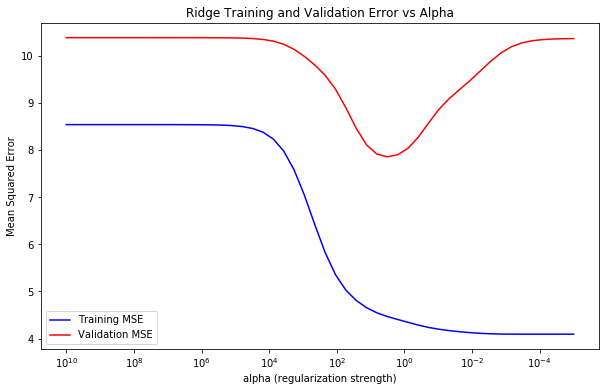

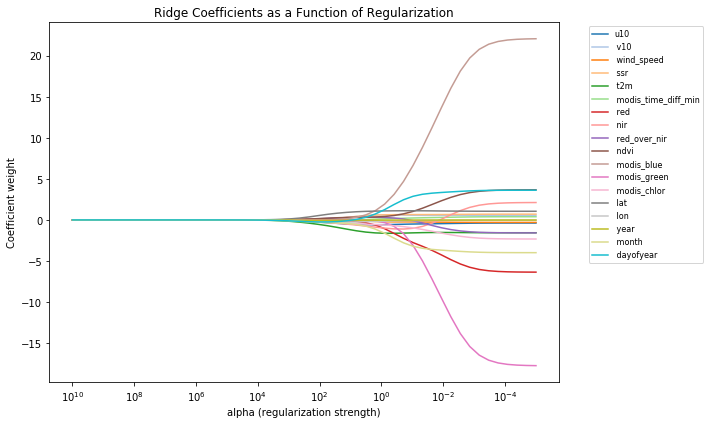

In [3]:
# define alpha range and cross-validation
alphas = np.logspace(-5, 10, 50)
#n_splits = 10
n_splits = 5
#test_size = 480  # ≈20 days
tscv = TimeSeriesSplit(n_splits=n_splits)

#tscv = TimeSeriesSplit(n_splits=n_splits)

# initialize arrays
coefs = np.zeros((len(alphas), X.shape[1]))
mse_train_ridge = np.zeros(len(alphas))
mse_valid_ridge = np.zeros(len(alphas))

# loop over alphas
for j, alpha in enumerate(alphas):
    #initialize lisst for coefs, mse
    fold_coefs = np.zeros((n_splits, X.shape[1]))
    fold_train_mse = []
    fold_valid_mse = []

    #loop through splits
    for i, (train_index, valid_index) in enumerate(tscv.split(X)):
        #extract train/valid data
        X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]
        

        # define pipeline
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=alpha, max_iter=10000))
        ])

        # fit on training data
        pipe.fit(X_train, y_train)
        #make predictions on training and validaiton set
        y_pred_train = pipe.predict(X_train)
        y_pred_valid = pipe.predict(X_valid)

        # store metrics
        fold_train_mse.append(mean_squared_error(y_train, y_pred_train))
        fold_valid_mse.append(mean_squared_error(y_valid, y_pred_valid))
        #extract coefs
        fold_coefs[i, :] = pipe.named_steps['ridge'].coef_

    # average over folds
    mse_train_ridge[j] = np.mean(fold_train_mse)
    mse_valid_ridge[j] = np.mean(fold_valid_mse)
    coefs[j, :] = np.mean(fold_coefs, axis=0)

# plot MSE vs alpha 
plt.figure(figsize=(10, 6))
ax = plt.gca()
plt.plot(alphas, mse_train_ridge, 'b', label='Training MSE')
plt.plot(alphas, mse_valid_ridge, 'r', label='Validation MSE')
ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])
plt.xlabel('alpha (regularization strength)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.title('Ridge Training and Validation Error vs Alpha')
plt.show()

# plot coefficient paths
colors = plt.get_cmap('tab20')
plt.figure(figsize=(10, 6))
ax = plt.gca()
for i, name in enumerate(feature_names):
    color = colors(i / len(feature_names))
    plt.plot(alphas, coefs[:, i], label=name, color=color)

ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])
plt.xlabel('alpha (regularization strength)')
plt.ylabel('Coefficient weight')
plt.title('Ridge Coefficients as a Function of Regularization')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/coordinate_descent.py:475: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 81.5306687283538, tolerance: 0.03801342857142857
  positive)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/coordinate_descent.py:475: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 233.53564433439823, tolerance: 0.11669944354838709
  positive)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/coordinate_descent.py:475: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 122.7677201168803, tolerance: 0.17273943783783785
  positive)
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/coordinate_descent.py:475: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 80.0803961

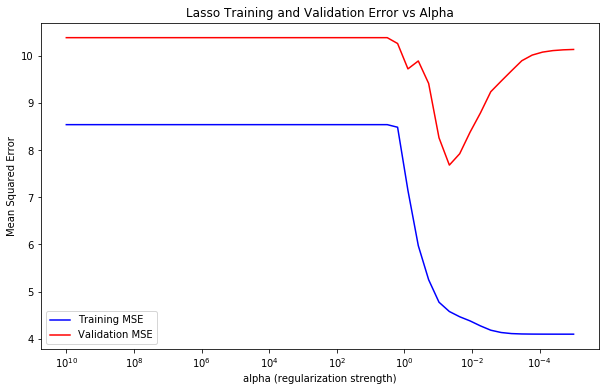

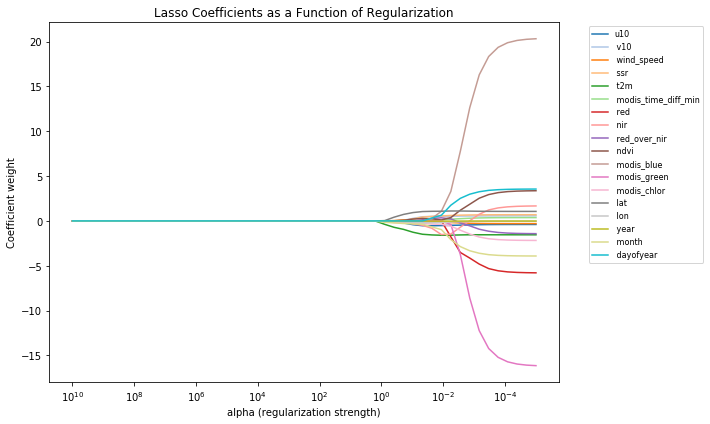

In [4]:
# define alpha range and cross-validation
alphas = np.logspace(-5, 10, 50)

#tscv = TimeSeriesSplit(n_splits=n_splits)
tscv = TimeSeriesSplit(n_splits=n_splits)
# initialize arrays
coefs = np.zeros((len(alphas), X.shape[1]))
mse_train_lasso = np.zeros(len(alphas))
mse_valid_lasso = np.zeros(len(alphas))

# loop over alphas
for j, alpha in enumerate(alphas):
    fold_coefs = np.zeros((n_splits, X.shape[1]))
    fold_train_mse = []
    fold_valid_mse = []


    for i, (train_index, valid_index) in enumerate(tscv.split(X)):
        X_train, X_valid = X.iloc[train_index], X.iloc[valid_index]
        y_train, y_valid = y.iloc[train_index], y.iloc[valid_index]

        # define pipeline
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('lasso', Lasso(alpha=alpha, max_iter=10000))
        ])

        # fit on training data
        pipe.fit(X_train, y_train)
        y_pred_train = pipe.predict(X_train)
        y_pred_valid = pipe.predict(X_valid)

        # store metrics
        fold_train_mse.append(mean_squared_error(y_train, y_pred_train))
        fold_valid_mse.append(mean_squared_error(y_valid, y_pred_valid))
        fold_coefs[i, :] = pipe.named_steps['lasso'].coef_

    # average over folds
    mse_train_lasso[j] = np.mean(fold_train_mse)
    mse_valid_lasso[j] = np.mean(fold_valid_mse)
    coefs[j, :] = np.mean(fold_coefs, axis=0)

# plot MSE vs alpha
plt.figure(figsize=(10, 6))
ax = plt.gca()
plt.plot(alphas, mse_train_lasso, 'b', label='Training MSE')
plt.plot(alphas, mse_valid_lasso, 'r', label='Validation MSE')
ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])
plt.xlabel('alpha (regularization strength)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.title('Lasso Training and Validation Error vs Alpha')
plt.show()

# plot coefficient paths
colors = plt.get_cmap('tab20')
plt.figure(figsize=(10, 6))
ax = plt.gca()
for i, name in enumerate(feature_names):
    color = colors(i / len(feature_names))
    plt.plot(alphas, coefs[:, i], label=name, color=color)

ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])
plt.xlabel('alpha (regularization strength)')
plt.ylabel('Coefficient weight')
plt.title('Lasso Coefficients as a Function of Regularization')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
#plot
fig=plt.figure(figsize=[10,6])
ax = plt.gca()
#plot ridge error
plt.plot(alphas, mse_valid_ridge, 'r', label = 'ridge validation error')
plt.plot(alphas, mse_train_ridge, 'b--',  label = 'ridge training error')
#plot lasso error
plt.plot(alphas, mse_valid_lasso, 'orange', label = 'lasso validation error')
plt.plot(alphas, mse_train_lasso, 'k--',  label = 'lasso training error')
#plot properties
ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])  # reverse axis
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.axis('tight')
plt.legend()
plt.show()
min_val_mse = min(mse_valid_lasso)
print(f'Lasso Validation RMSE = {np.sqrt(min_val_mse)}')
min_val_mse_idx = np.where(mse_valid_lasso == min_val_mse)[0]
print(alphas[min_val_mse_idx])

In [ ]:
### Model 2: Support Vector Regression

In [15]:
# imports
#from scipy.stats import loguniform
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

# reproducibility
RANDOM_STATE = 42

# time series CV
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# pipeline (keep consistent step names)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# broad randomized search space
param_dist = {
    'svr__kernel': ['rbf', 'linear'],
    'svr__C': np.logspace(-2, 3, 20),       # 1e-2 to 1e3
    'svr__epsilon': np.logspace(-4, -1, 10),# 1e-4 to 1e-1
    'svr__gamma': np.logspace(-4, 1, 15),   # 1e-4 to 1e1
    'svr__degree': [2, 3]
}

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=20,                       # adjust for compute budget
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True
)

# run randomized search
rs.fit(X, y)
print("Random search best params:", rs.best_params_)
print("Random search best CV RSME:", np.sqrt(-rs.best_score_))

# build small deterministic grid around best numeric values (only when numeric)
best = rs.best_params_.copy()

# helper to safely get numeric floats (if present)
def _get_float(d, key, fallback, factor_low=0.5, factor_high=5.0, num=6):
    val = d.get(key)
    if val is None:
        return np.logspace(np.log10(fallback*factor_low), np.log10(fallback*factor_high), num)
    try:
        v = float(val)
        return np.linspace(v*factor_low, v*factor_high, num)
    except Exception:
        return [val]

grid = {
    'svr__kernel': [best['svr__kernel']],
    'svr__C': _get_float(best, 'svr__C', 1.0, num=8),
    'svr__epsilon': _get_float(best, 'svr__epsilon', 1e-3, num=6)
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

gs.fit(X, y)
print("Grid-refined best params:", gs.best_params_)
print("Grid-refined best CV RMSE:", np.sqrt(-gs.best_score_))

# final evaluation with cross_validate (gives per-fold metrics cleanly)
scoring = {
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res = cross_validate(gs.best_estimator_, X, y, cv=tscv, scoring=scoring, return_train_score=True, n_jobs=-1)

# convert/print readable metrics
def _summ(metric, sign_adjust=False):
    vals = cv_res[metric]
    if sign_adjust: vals = -vals
    return vals.mean(), vals.std()

svr_rmse_mean, svr_rmse_std = _summ('test_rmse')
svr_mae_mean, svr_mae_std   = _summ('test_mae', sign_adjust=True)
svr_r2_mean, svr_r2_std     = _summ('test_r2')

print(f"Final (CV) RMSE: {svr_rmse_mean:.4f} ± {svr_rmse_std:.4f}")
print(f"Final (CV) MAE:  {svr_mae_mean:.4f} ± {svr_mae_std:.4f}")
print(f"Final (CV) R2:   {svr_r2_mean:.4f} ± {svr_r2_std:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    6.0s finished
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:724: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Random search best params: {'svr__kernel': 'rbf', 'svr__gamma': 0.07196856730011521, 'svr__epsilon': 0.021544346900318822, 'svr__degree': 2, 'svr__C': 0.6951927961775606}
Random search best CV RSME: 2.6073549759766617
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Grid-refined best params: {'svr__C': 2.135235016831079, 'svr__epsilon': 0.08833182229130718, 'svr__kernel': 'rbf'}
Grid-refined best CV RMSE: 2.5733428614360077
Final (CV) RMSE: 2.5356 ± 0.4390
Final (CV) MAE:  1.9721 ± 0.3119
Final (CV) R2:   0.1279 ± 0.2186


[Parallel(n_jobs=-1)]: Done 240 out of 240 | elapsed:    0.5s finished
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:724: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


without lat, lon, year, month, dayofyear as features: the RMSE= 3.039, MAE=2.4, R2= -0.916

In [ ]:
### Model 3: Random Forest Regressor

In [16]:
# imports
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

# reproducibility
RANDOM_STATE = 42

# time-series CV
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# pipeline - scaler is optional for RF; left out to keep it minimal (add if you like)
pipe = Pipeline([('rfr', RandomForestRegressor(random_state=RANDOM_STATE))])

# randomized search space
param_dist = {
    'rfr__n_estimators': randint(100, 500),
    'rfr__max_depth': randint(3, 30),
    'rfr__min_samples_split': randint(2, 10),
    'rfr__min_samples_leaf': randint(1, 6),
    'rfr__max_features': uniform(0.3, 0.7),  # draws in [0.3, 1.0)
    'rfr__bootstrap': [True, False]
}

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True
)

# run random search
rs.fit(X, y)
print("Random search best params:", rs.best_params_)
print("Random search best CV RMSE:", np.sqrt(-rs.best_score_))

# --- build a sane grid around numeric best values ---
best = rs.best_params_.copy()

def _make_linear_space(val, low_factor=0.7, high_factor=1.3, num=5, min_val=None, max_val=None):
    """Return a small linspace around val; if val is not float/int, return [val]."""
    try:
        v = float(val)
    except Exception:
        return [val]
    lo, hi = v * low_factor, v * high_factor
    if min_val is not None: lo = max(lo, min_val)
    if max_val is not None: hi = min(hi, max_val)
    if lo == hi:
        return [v]
    # if integer-like parameters, cast to int and unique
    if abs(v - round(v)) < 1e-6:
        arr = np.linspace(int(max(1, round(lo))), int(round(hi)), num, dtype=int)
        return sorted(set(arr))
    return np.linspace(lo, hi, num)

grid = {
    'rfr__n_estimators': _make_linear_space(best.get('rfr__n_estimators', 200), low_factor=0.8, high_factor=1.25, num=5, min_val=50),
    'rfr__max_depth': _make_linear_space(best.get('rfr__max_depth', 10), low_factor=0.7, high_factor=1.3, num=5, min_val=2),
    'rfr__min_samples_split': _make_linear_space(best.get('rfr__min_samples_split', 2), low_factor=0.6, high_factor=1.5, num=4, min_val=2),
    'rfr__min_samples_leaf': _make_linear_space(best.get('rfr__min_samples_leaf', 1), low_factor=0.5, high_factor=2.0, num=4, min_val=1),
    # max_features must be in (0,1] if float; clamp to reasonable range
    'rfr__max_features': np.unique(np.clip(_make_linear_space(best.get('rfr__max_features', 0.5), low_factor=0.8, high_factor=1.1, num=4, min_val=0.01, max_val=1.0), 0.01, 1.0)).tolist(),
    'rfr__bootstrap': [best.get('rfr__bootstrap', True)]
}

# Grid search
gs = GridSearchCV(
    estimator=pipe,
    param_grid=grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

gs.fit(X, y)
print("Grid-refined best params:", gs.best_params_)
print("Grid-refined best CV RMSE:", np.sqrt(-gs.best_score_))

# final evaluation using cross_validate to get per-fold stats
scoring = {
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res = cross_validate(gs.best_estimator_, X, y, cv=tscv, scoring=scoring, return_train_score=True, n_jobs=-1)

def mean_std(key, sign_adjust=False):
    vals = cv_res[key]
    if sign_adjust:
        vals = -vals
    return vals.mean(), vals.std()

rf_rmse_mean, rf_rmse_std = mean_std('test_rmse')
rf_mae_mean, rf_mae_std   = mean_std('test_mae', sign_adjust=True)
rf_r2_mean, rf_r2_std     = mean_std('test_r2')

print(f"Final (CV) RMSE: {rf_rmse_mean:.4f} ± {rf_rmse_std:.4f}")
print(f"Final (CV) MAE:  {rf_mae_mean:.4f} ± {rf_mae_std:.4f}")
print(f"Final (CV) R2:   {rf_r2_mean:.4f} ± {rf_r2_std:.4f}")

# show training error if you care
train_rmse_mean, train_rmse_std = cv_res['train_rmse'].mean(), cv_res['train_rmse'].std()
print(f"Train RMSE (CV folds): {train_rmse_mean:.4f} ± {train_rmse_std:.4f}")

# feature importances from the fitted estimator (GridSearch refit)
final_rfr = gs.best_estimator_.named_steps['rfr']
if hasattr(final_rfr, 'feature_importances_'):
    importances = final_rfr.feature_importances_
    # show top 10 features (if X is array with unknown names)
    top_idx = np.argsort(importances)[::-1][:10]
    print("Top feature importances (idx: importance):")
    for i in top_idx:
        print(f"  {feature_names[i]}: {importances[i]:.4f}")
else:
    print("Final estimator doesn't expose feature_importances_.")


Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   11.6s finished
/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py:356: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params)


Random search best params: {'rfr__bootstrap': True, 'rfr__max_depth': 21, 'rfr__max_features': 0.322000429980714, 'rfr__min_samples_leaf': 1, 'rfr__min_samples_split': 5, 'rfr__n_estimators': 195}
Random search best CV RMSE: 2.417289078243935
Fitting 5 folds for each of 800 candidates, totalling 4000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   16.5s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:   30.0s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:   46.9s
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 2434 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 3184 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 4000 out of 4000 | elapsed:  2.5min finished
/opt/conda/lib/python3.7/site-packages/sklearn/pipeline.py:356: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params)


Grid-refined best params: {'rfr__bootstrap': True, 'rfr__max_depth': 15, 'rfr__max_features': 0.32200042998071404, 'rfr__min_samples_leaf': 1, 'rfr__min_samples_split': 4, 'rfr__n_estimators': 222}
Grid-refined best CV RMSE: 2.396744401037878
Final (CV) RMSE: 2.3629 ± 0.4016
Final (CV) MAE:  1.7843 ± 0.3134
Final (CV) R2:   0.2440 ± 0.1800
Train RMSE (CV folds): 1.3578 ± 0.0494
Top feature importances (idx: importance):
   modis_chlor: 0.2001
   modis_green: 0.1398
   ndvi: 0.1062
   v10: 0.0989
   modis_blue: 0.0897
  u10: 0.0711
   t2m: 0.0558
   wind_speed: 0.0529
   modis_time_diff_min: 0.0440
   ssr: 0.0391


Most important features before adding mroe: 2m temperature, ndvi, and red/nir

without lat, lon, year, month, dayofyear as features: the RMSE= 3.0839, MAE=2.53, R2= -0.89
with these new features: RMSE= 2.7, MAE = 2.14, R2= -0.43

Random forest seems to do the best by a little bit, this predicts using the entire dataset (the same data the model was trained on, no split)

Full dataset RMSE: 1.4768
Full dataset MAE:  0.9701
Full dataset R2:   0.7588


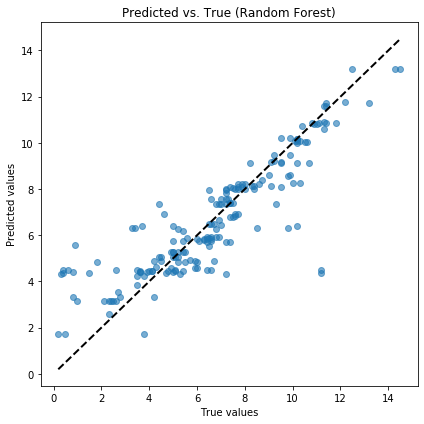

In [5]:
#want to see how model does when predicting over the entire dataset and visual the results, not really great practice but was curious
# Predict using the best estimator from grid search
y_pred = gs.best_estimator_.predict(X)

# Evaluate overall metrics on the full dataset
rmse_full = np.sqrt(mean_squared_error(y, y_pred))
mae_full  = mean_absolute_error(y, y_pred)
r2_full   = r2_score(y, y_pred)

print(f"Full dataset RMSE: {rmse_full:.4f}")
print(f"Full dataset MAE:  {mae_full:.4f}")
print(f"Full dataset R2:   {r2_full:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # 1:1 line
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Predicted vs. True (Random Forest)")
plt.tight_layout()
plt.show()

In [13]:
#this is all commented out becuase it doesn't show much and it uses the entire X set the model was trained on, so not great
# import geopandas as gpd
# from shapely.geometry import Point

# #want to map the actual and predicted DO
# df_compare = pd.DataFrame({
#     'lat':X[' lat'],
#     'lon':X[' lon'],
#     'DO_actual': np.ravel(y),
#     'DO_pred': y_pred
# })
# # Convert to GeoDataFrame
# geometry = [Point(xy) for xy in zip(df_compare["lon"], df_compare["lat"])]
# gdf = gpd.GeoDataFrame(df_compare, geometry=geometry, crs="EPSG:4326")  # WGS84

# fig, axes = plt.subplots(1, 2, figsize=(12,8), dpi=300)

# # Shared color limits
# vmin = min(gdf["DO_actual"].min(), gdf["DO_pred"].min())
# vmax = max(gdf["DO_actual"].max(), gdf["DO_pred"].max())

# # Actual DO
# gdf.plot(column="DO_actual", cmap="viridis", legend=False, ax=axes[0], markersize=40, vmin=vmin, vmax=vmax)
# axes[0].set_title("Actual DO")

# # Predicted DO
# gdf.plot(column="DO_pred", cmap="viridis", legend=False, ax=axes[1], markersize=40, vmin=vmin, vmax=vmax)
# axes[1].set_title("Predicted DO")

# # Add one shared colorbar
# sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=vmin, vmax=vmax))
# sm._A = []  # dummy array for colorbar
# cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])  
# cbar = fig.colorbar(sm, cax=cbar_ax)
# cbar.set_label("DO")

# plt.tight_layout()
# plt.show()
#this doesn't actually show that much lol

In [ ]:
### Model 4: Gradient Boosting Regressor

In [17]:
# working GradientBoostingRegressor tuning pipeline (time-series CV)
import warnings
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import randint, uniform
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

# reproducibility
RANDOM_STATE = 42

# time-series CV
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# pipeline
pipe = Pipeline([
    # add preprocessing here if needed
    ('gb', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

# randomized search space (use sensible ranges)
param_dist = {
    'gb__n_estimators': randint(100, 1000),
    'gb__max_depth': randint(2, 8),
    'gb__learning_rate': uniform(0.01, 0.29),   # 0.01 - 0.30
    'gb__min_samples_split': randint(2, 20),
    'gb__min_samples_leaf': randint(1, 20),
    'gb__subsample': uniform(0.6, 0.4),         # 0.6 - 1.0
    'gb__max_features': uniform(0.3, 0.7)       # 0.3 - 1.0 (as fraction)
}

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True
)

# run random search
rs.fit(X, y)
print("Random search best params:", rs.best_params_)
print("Random search best CV RMSE:", np.sqrt(-rs.best_score_))

# --- build a sane grid around numeric best values ---
best = rs.best_params_.copy()

def _make_linear_space(val, low_factor=0.7, high_factor=1.3, num=5, min_val=None, max_val=None):
    """Return a small linspace around val; if val is not float/int, return [val]."""
    try:
        v = float(val)
    except Exception:
        return [val]
    lo, hi = v * low_factor, v * high_factor
    if min_val is not None: lo = max(lo, min_val)
    if max_val is not None: hi = min(hi, max_val)
    if lo == hi:
        return [v]
    # integer-like parameters cast to int and unique
    if abs(v - round(v)) < 1e-6:
        arr = np.linspace(int(max(1, round(lo))), int(round(hi)), num, dtype=int)
        return sorted(set(arr.tolist()))
    return np.linspace(lo, hi, num).tolist()

# create grid using the keys used in the pipeline ('gb__...')
grid = {
    'gb__n_estimators': [best['gb__n_estimators'] - 50, best['gb__n_estimators'], best['gb__n_estimators'] + 50],
    'gb__learning_rate': [best['gb__learning_rate'] * f for f in [0.8, 1.0, 1.2]],
    'gb__max_depth': [best['gb__max_depth'] - 1, best['gb__max_depth'], best['gb__max_depth'] + 1],
}

# Grid search
gs = GridSearchCV(
    estimator=pipe,
    param_grid=grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    refit=True
)

gs.fit(X, y)
print("Grid-refined best params:", gs.best_params_)
print("Grid-refined best CV RMSE:", np.sqrt(-gs.best_score_))

# final evaluation using cross_validate to get per-fold stats
scoring = {
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res = cross_validate(gs.best_estimator_, X, y, cv=tscv, scoring=scoring, return_train_score=True, n_jobs=-1)

def mean_std(key, sign_adjust=False):
    vals = cv_res[key]
    if sign_adjust:
        vals = -vals
    return vals.mean(), vals.std()

gb_rmse_mean, gb_rmse_std = mean_std('test_rmse')
gb_mae_mean, gb_mae_std   = mean_std('test_mae', sign_adjust=True)
gb_r2_mean, gb_r2_std     = mean_std('test_r2')

print(f"Final (CV) RMSE: {gb_rmse_mean:.4f} ± {gb_rmse_std:.4f}")
print(f"Final (CV) MAE:  {gb_mae_mean:.4f} ± {gb_mae_std:.4f}")
print(f"Final (CV) R2:   {gb_r2_mean:.4f} ± {gb_r2_std:.4f}")

# show training error if you care
train_rmse_mean, train_rmse_std = cv_res['train_rmse'].mean(), cv_res['train_rmse'].std()
print(f"Train RMSE (CV folds): {train_rmse_mean:.4f} ± {train_rmse_std:.4f}")

# feature importances from the fitted estimator (GridSearch refit)
final_gb = gs.best_estimator_.named_steps['gb']
if hasattr(final_gb, 'feature_importances_'):
    importances = final_gb.feature_importances_
    # show top 10 features (if X is array with unknown names)
    top_idx = np.argsort(importances)[::-1][:10]
    print("Top feature importances (idx: importance):")
    for i in top_idx:
        print(f"  {feature_names[i]}: {importances[i]:.6f}")
else:
    print("Final estimator doesn't expose feature_importances_.")


Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    6.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Random search best params: {'gb__learning_rate': 0.03161968666713354, 'gb__max_depth': 2, 'gb__max_features': 0.8405713385076601, 'gb__min_samples_leaf': 12, 'gb__min_samples_split': 9, 'gb__n_estimators': 571, 'gb__subsample': 0.6056319290860338}
Random search best CV RMSE: 2.3632440817206994
Fitting 5 folds for each of 27 candidates, totalling 135 fits


[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 120 out of 135 | elapsed:    2.9s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done 135 out of 135 | elapsed:    3.3s finished


Grid-refined best params: {'gb__learning_rate': 0.03161968666713354, 'gb__max_depth': 1, 'gb__n_estimators': 521}
Grid-refined best CV RMSE: 2.3050973906256336
Final (CV) RMSE: 2.2732 ± 0.3824
Final (CV) MAE:  1.7297 ± 0.3186
Final (CV) R2:   0.3012 ± 0.1583
Train RMSE (CV folds): 1.7394 ± 0.1099
Top feature importances (idx: importance):
   modis_chlor: 0.444527
   ndvi: 0.258113
   modis_blue: 0.105204
   v10: 0.075585
   modis_green: 0.044967
  u10: 0.039532
   modis_time_diff_min: 0.012102
   t2m: 0.008931
   wind_speed: 0.005347
   red_over_nir: 0.004902


without lat, lon, year, month, dayofyear as features: the RMSE= 3.4492, MAE=2.7825, R2= -1.247

In [ ]:
### Model 5: MLP

In [18]:
# MLP tuning pipeline with fit-count cap (~2000 total fits)
import numpy as np
import warnings
from math import floor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.neural_network import MLPRegressor
from scipy.stats import randint, uniform

In [19]:
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

# TimeSeries CV (change n_splits if you want)
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Upper cap on total fitted models (including CV folds)
MAX_TOTAL_FITS = 2000
# reserve some slots for the small grid refinement
GRID_COMBOS_TARGET = 30

# compute allowed number of parameter sets to evaluate (per-CV combo)
allowed_param_sets = max(10, floor(MAX_TOTAL_FITS / n_splits))
# allocate to random search first, leaving room for grid
n_iter_rs = max(10, allowed_param_sets - GRID_COMBOS_TARGET)
# but don't make n_iter too big (practical cap)
n_iter_rs = min(n_iter_rs, 800)

print(f"n_splits={n_splits}, allowed_param_sets={allowed_param_sets}, n_iter_random={n_iter_rs}, grid_targets≈{GRID_COMBOS_TARGET}")

# Pipeline (MLP needs scaling)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(random_state=RANDOM_STATE, early_stopping=True, validation_fraction=0.1,
                         n_iter_no_change=10, tol=1e-4, max_iter=200))
])

# Randomized search space (sensible ranges for MLP)
# For hidden_layer_sizes we provide a sampled list of plausible architectures
hidden_choices = [
    (50,), (100,), (200,), (50, 25), (100, 50), (100, 100), (200, 100),
    (50, 50, 25), (100, 50, 25)
]

param_dist = {
    'mlp__hidden_layer_sizes': hidden_choices,
    'mlp__activation': ['relu', 'tanh'],           # 'identity' and 'logistic' are less common
    'mlp__solver': ['adam'],                       # use 'adam' (works well with early stopping)
    'mlp__alpha': uniform(1e-6, 1e-2),             # L2 penalty: 1e-6 .. 1e-2
    'mlp__learning_rate_init': uniform(1e-4, 5e-2),# 0.0001 .. 0.0501
    'mlp__batch_size': randint(32, 256),           # mini-batch sizes
    # you can also try learning_rate: 'constant' or 'adaptive'
    'mlp__learning_rate': ['constant', 'adaptive']
}

rs = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=n_iter_rs,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0,
    random_state=RANDOM_STATE,
    refit=True
)

# Run randomized search (coarse search)
rs.fit(X, y)
print("Random search best params:", rs.best_params_)
print("Random search best CV RMSE:", np.sqrt(-rs.best_score_))

# Build a small grid around the best random params (keep total combos small)
best = rs.best_params_.copy()

def _neighbor_layer_sizes(hls):
    """Generate a small set of nearby architectures around the chosen hidden_layer_sizes tuple."""
    if not isinstance(hls, tuple):
        try:
            hls = tuple(hls)
        except Exception:
            return [(50,)]
    res = set()
    base = list(hls)
    # keep original
    res.add(tuple(base))
    # increase/decrease neurons by ~20% (rounded)
    for i in range(len(base)):
        for factor in (0.8, 1.2):
            nb = base.copy()
            nb[i] = max(1, int(round(nb[i] * factor)))
            res.add(tuple(nb))
    # add/shrink depth by +/-1 layer (copy nearest size for new layer)
    if len(base) < 3:
        # add a smaller layer at end
        extra = max(1, int(round(base[-1] * 0.5)))
        res.add(tuple(base + [extra]))
    if len(base) > 1:
        # remove last layer
        res.add(tuple(base[:-1]))
    # some fixed alternatives
    res.update([(max(10, int(round(x*0.5))),) for x in base])
    return sorted(res)

# create small lists for grid (max combos ~ GRID_COMBOS_TARGET)
hls_grid = _neighbor_layer_sizes(best.get('mlp__hidden_layer_sizes', (100,)))
lr_grid = np.unique(np.clip(np.array([
    best.get('mlp__learning_rate_init', 0.001) * f for f in [0.5, 0.8, 1.0, 1.2, 1.5]
]), 1e-6, 1.0)).tolist()
alpha_grid = np.unique(np.clip(np.array([
    best.get('mlp__alpha', 1e-4) * f for f in [0.5, 1.0, 2.0, 5.0]
]), 1e-8, 1.0)).tolist()
batch_grid = sorted(set([
    best.get('mlp__batch_size', 64),
    max(16, int(best.get('mlp__batch_size', 64) // 2)),
    min(512, int(best.get('mlp__batch_size', 64) * 2))
]))

act_grid = [best.get('mlp__activation', 'relu')]
if act_grid[0] == 'relu':
    act_grid.append('tanh')
else:
    act_grid.append('relu')

lr_type_grid = [best.get('mlp__learning_rate', 'constant')]

# Build grid dict but keep it small — limit combinations
grid = {
    'mlp__hidden_layer_sizes': hls_grid[:6],  # cap number to keep combos small
    'mlp__learning_rate_init': lr_grid[:4],
    'mlp__alpha': alpha_grid[:4],
    'mlp__batch_size': batch_grid[:3],
    'mlp__activation': act_grid,
    'mlp__learning_rate': lr_type_grid
}

# estimate combos
from functools import reduce
from operator import mul
combo_counts = [len(v) for v in grid.values()]
total_combos = reduce(mul, combo_counts, 1)
print("Grid combos:", combo_counts, "=> total combos:", total_combos, "=> total fits (~):", total_combos * n_splits)

# If grid is still too big, trim some lists
MAX_GRID_COMBOS = max(1, GRID_COMBOS_TARGET)
if total_combos > MAX_GRID_COMBOS:
    # simple trim strategy: reduce each list to at most ceil(root_k) where root_k is kth-root
    import math
    target_per_param = int(math.ceil(MAX_GRID_COMBOS ** (1.0 / len(grid))))
    for k in list(grid.keys()):
        grid[k] = grid[k][:max(1, target_per_param)]
    combo_counts = [len(v) for v in grid.values()]
    total_combos = reduce(mul, combo_counts, 1)
    print("Trimmed grid combos:", combo_counts, "=> total combos now:", total_combos, "=> fits:", total_combos * n_splits)

# Grid search (small)
gs = GridSearchCV(
    estimator=pipe,
    param_grid=grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0,
    refit=True
)

gs.fit(X, y)
print("Grid-refined best params:", gs.best_params_)
print("Grid-refined best CV RMSE:", np.sqrt(-gs.best_score_))

# Final cross-validated metrics
scoring = {
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_res = cross_validate(gs.best_estimator_, X, y, cv=tscv, scoring=scoring, return_train_score=True, n_jobs=-1)

def mean_std(key, sign_adjust=False):
    vals = cv_res[key]
    if sign_adjust:
        vals = -vals
    return vals.mean(), vals.std()

mlp_rmse_mean, mlp_rmse_std = mean_std('test_rmse')
mlp_mae_mean, mlp_mae_std   = mean_std('test_mae', sign_adjust=True)
mlp_r2_mean, mlp_r2_std     = mean_std('test_r2')

print(f"Final (CV) RMSE: {mlp_rmse_mean:.4f} ± {mlp_rmse_std:.4f}")
print(f"Final (CV) MAE:  {mlp_mae_mean:.4f} ± {mlp_mae_std:.4f}")
print(f"Final (CV) R2:   {mlp_r2_mean:.4f} ± {mlp_r2_std:.4f}")

# final estimator
final_mlp = gs.best_estimator_.named_steps['mlp']
print("Final MLP iterations:", getattr(final_mlp, 'n_iter_', 'n_iter_ not available on this sklearn version'))

n_splits=5, allowed_param_sets=400, n_iter_random=370, grid_targets≈30
Random search best params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.004488775738314031, 'mlp__batch_size': 107, 'mlp__hidden_layer_sizes': (100, 50, 25), 'mlp__learning_rate': 'constant', 'mlp__learning_rate_init': 0.022571691760686886, 'mlp__solver': 'adam'}
Random search best CV RMSE: 2.5933981886762463
Grid combos: [6, 4, 4, 3, 2, 1] => total combos: 576 => total fits (~): 2880
Trimmed grid combos: [2, 2, 2, 2, 2, 1] => total combos now: 32 => fits: 160
Grid-refined best params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.004488775738314031, 'mlp__batch_size': 53, 'mlp__hidden_layer_sizes': (12,), 'mlp__learning_rate': 'constant', 'mlp__learning_rate_init': 0.01805735340854951}
Grid-refined best CV RMSE: 2.7630390084455105
Final (CV) RMSE: 2.6849 ± 0.6526
Final (CV) MAE:  2.1089 ± 0.5738
Final (CV) R2:   0.0181 ± 0.3598
Final MLP iterations: 54


without lat, lon, year, month, dayofyear as features: the RMSE= 4.1242, MAE=3.356, R2= -2.6061

### compare the different models

In [20]:
results = {
    "Random Forest": {"RMSE": rf_rmse_mean, "MAE": rf_mae_mean, "R2": rf_r2_mean},
    "Gradient Boosting": {"RMSE": gb_rmse_mean, "MAE": gb_mae_mean, "R2": gb_r2_mean},
    "MLP": {"RMSE": mlp_rmse_mean, "MAE": mlp_mae_mean, "R2": mlp_r2_mean},
    "SVR": {"RMSE": svr_rmse_mean, "MAE": svr_mae_mean, "R2": svr_r2_mean},
}
results

{'Random Forest': {'RMSE': 2.362861979274867,
  'MAE': 1.7843069595971883,
  'R2': 0.24399169005914959},
 'Gradient Boosting': {'RMSE': 2.2731504549581896,
  'MAE': 1.7296916105439404,
  'R2': 0.30120859550345036},
 'MLP': {'RMSE': 2.6848611397832314,
  'MAE': 2.1089291182344523,
  'R2': 0.018057837403126296},
 'SVR': {'RMSE': 2.5356134509208905,
  'MAE': 1.9721377215348852,
  'R2': 0.12790699669890176}}

#### Just to test simple linear regression

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)
lin_reg = LinearRegression()

nmse_scores = -cross_val_score(
    lin_reg, X, y,
    scoring="neg_mean_squared_error",
    cv=tscv
)

rmse_scores = np.sqrt(nmse_scores)

print("Time-Series CV RMSE:", (rmse_scores))
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

Time-Series CV RMSE: [3.60596862 2.81005137 2.37973574 2.86409865 2.5153104 ]
Mean RMSE: 2.8350329557069736
Std RMSE: 0.4255182152211839


## Preparing Data for model prediction

#### loading era5

In [49]:
#era5 data that was not used for model training

import xarray as xr
#era5 data
file = '/shared_space/Galveston_Bay/ERA5/ERA5-2018-2020_rescaled.nc'
ds = xr.open_dataset(file)
#want data that was not used to train model
ds_ERA = ds.valid_time.to_index()
unused_times = ds_ERA.difference(X_dates)
test_ERA = ds.sel(valid_time=unused_times)
#test_ERA

#### loading modis

In [67]:
#modis data that was not used for training
#load and group the MODIS red, nir, and qc by date
import glob
from collections import defaultdict
import re
import datetime as datetime
os.chdir('/home/jovyan')

# define functions
# parse date from filename
def parse_date(file):
    # find the 'doyYYYYJJJ...' pattern (e.g. doy2019364000000 -> capture '2019364')
    m = re.search(r'doy(\d{7})', os.path.basename(file))
    if m:
        return m.group(1)
    
#convert key to timestamp
def string_to_timestamp(yyyydoy):
    year = int(yyyydoy[:4])
    doy  = int(yyyydoy[4:7])
    return pd.to_datetime(f"{year}-{doy}", format="%Y-%j")

files_500m_2020 = glob.glob('./shared_space/Galveston_Bay/MODIS_500/bands2020/*')
files_500m_2019 = glob.glob('./shared_space/Galveston_Bay/MODIS_500/*2019*')
files_500m_2018 = glob.glob('./shared_space/Galveston_Bay/MODIS_500/bands2018/*')

all_modis = files_500m_2020 + files_500m_2019 + files_500m_2018
all_files = sorted(all_modis)

# group files by datetime
groups = defaultdict(list)
for file in all_files:
    key = parse_date(file)
    #groups[key].append(file)
    if key is None:
        continue      # skip files without a valid date
    groups[key].append(file)
#check
print(len(groups))

1094


In [63]:
keys = list(groups.keys())   #extract filenames in groups            
times = np.array([string_to_timestamp(k) for k in keys])
index = pd.DatetimeIndex(times)

In [69]:
# configurations
SCALE = 0.0001                # MODIS SUR_REFL scale factor
TIME_TOL = pd.Timedelta("96h")# max allowed difference between obs and MODIS scene
USE_FALLBACK = True          # set True to enable KDTree fallback (more expensive)
FALLBACK_MAX_KM = 100.0        # max distance to accept fallback pixel

def year_doy_to_ts(yyyydoy):
    # yyyydoy can be either string '2019001' or a tuple (year,doy)
    if isinstance(yyyydoy, str) and len(yyyydoy) >= 7:
        year = int(yyyydoy[:4])
        doy  = int(yyyydoy[4:7])
        return pd.to_datetime(datetime(year, 1, 1) + timedelta(days=doy-1))
    # if it's already a Timestamp or date
    return pd.to_datetime(yyyydoy)

# extract YYYYDDD from filename
def extract_year_doy(s):
    if s is None:
        return None
    s = str(s)
    m = re.search(r'doy(\d{7})', s, flags=re.IGNORECASE)
    if m:
        return m.group(1)
    m2 = re.search(r'(\d{4})(\d{3})', s)
    if m2:
        return m2.group(1) + m2.group(2)
    return None

In [70]:
raw_keys = list(groups.keys())   # your original keys (strings like '2019001' or date objects)
scene_tuples = []   # list of (orig_key, parsed_ts, orig_pos)

for pos, k in enumerate(raw_keys):
    try:
        ek = extract_year_doy(k)   # your function that returns yyyydoy string or None
    except Exception:
        ek = None

    if ek is None:
        # keep track of bad keys if you want
        bad_keys.append(k)
        continue

    ts = year_doy_to_ts(ek)   # convert to pandas Timestamp
    if pd.isna(ts):
        bad_keys.append(k)
        continue

    scene_tuples.append((k, ts, pos))

if len(scene_tuples) == 0:
    raise RuntimeError("No valid scene keys parsed from groups.")

# sort by timestamp (chronological order) -> this gives a monotonic index for get_indexer
scene_tuples_sorted = sorted(scene_tuples, key=lambda t: t[1])

# Build sorted scene_index (monotonic increasing)
sorted_timestamps = [t[1] for t in scene_tuples_sorted]
scene_index = pd.DatetimeIndex(sorted_timestamps)

# Also build mapping: sorted-position -> original position and -> original key
sortedpos_to_origpos = [t[2] for t in scene_tuples_sorted]   # list indexed by sorted position
sortedpos_to_origkey = [t[0] for t in scene_tuples_sorted]    # same length, original keys

TypeError: 'module' object is not callable

### code below has packages not imported into the container- if we want to use them, we should talk to Nate about importing them, but I don't think we really need to use them

In [ ]:
### Model 6: Generalized Additive Model

In [83]:
import numpy as np
from functools import reduce
import operator
from pygam import LinearGAM, s
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math
import matplotlib.pyplot as plt

In [84]:
# --- prepare terms ---
n_features = X.shape[1]
terms_list = (s(i) for i in range(n_features))
terms = reduce(operator.add, terms_list)   # TermList

# --- param grid (tune these to control total # fits) ---
# Keep sizes small if n_splits is large. Example below: 6 * 3 = 18 combos per fold.
#lams  =   np.logspace(-3, 3, 10)
lams = np.random.rand(100, 5) # random points on [0, 1], with shape (100, 3)
lams = lams * 6 - 3 # shift values to -3, 3
lams = 10 ** lams # transforms values to 1e-3, 1e3
# --- TimeSeries CV + GAM gridsearch per-fold ---
tscv = TimeSeriesSplit(n_splits=12)

r2_vals, rmse_vals, mae_vals, mse_train_vals = [], [], [], []
last_fitted_gam = None
last_scaler = None

for fold, (train_idx, valid_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_valid = X[train_idx], X[valid_idx]
    y_train, y_valid = y[train_idx], y[valid_idx]

    scaler = StandardScaler().fit(X_train)
    X_tr_s = scaler.transform(X_train)
    X_val_s = scaler.transform(X_valid)
    
    # Create the gam and run gridsearch ON THE TRAINING DATA only
    gam = LinearGAM(terms)
    gam = gam.gridsearch(X_tr_s, y_train, lam=lams, progress=False)

    # Now predict (do NOT call gridsearch on the validation set)
    y_pred_val = gam.predict(X_val_s)
    y_pred_train = gam.predict(X_tr_s)

    r2 = r2_score(y_valid, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred_val))
    mae = mean_absolute_error(y_valid, y_pred_val)
    mse_train = mean_squared_error(y_train, y_pred_train)

    r2_vals.append(r2); rmse_vals.append(rmse); mae_vals.append(mae); mse_train_vals.append(mse_train)

    print(f"Fold {fold}: R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, train MSE={mse_train:.4f}")

    last_fitted_gam = gam
    last_scaler = scaler

print("Mean valid R2:   ", np.mean(r2_vals))
print("Mean valid RMSE: ", np.mean(rmse_vals))
print("Mean valid MAE:  ", np.mean(mae_vals))
print("Mean train MSE:  ", np.mean(mse_train_vals))

# --- Final refit on all data using the same (or a slightly expanded) grid ---
scaler_all = StandardScaler().fit(X)
X_all_s = scaler_all.transform(X)
gam_final = LinearGAM(terms).gridsearch(X_all_s, y, lam=lams, progress=False)

In [82]:
# --- Partial dependence plots for each feature (3-row layout) ---
n_rows = 3
n_cols = math.ceil(n_features / n_rows)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axs = axs.flatten()

for i in range(n_features):
    ax = axs[i]
    XX = gam_final.generate_X_grid(term=i)
    # partial_dependence can return (pdep) or (pdep, conf) depending on args / version:
    # Trying to retrieve pdep and confidence interval safely:
    try:
        pdep = gam_final.partial_dependence(term=i, X=XX)
        # confidence interval using partial_dependence with width (some pygam versions return a tuple)
        pd_with_ci = gam_final.partial_dependence(term=i, X=XX, width=0.95)
        if isinstance(pd_with_ci, tuple) and len(pd_with_ci) == 2:
            pdep, conf = pd_with_ci
            lower, upper = conf[:, 0], conf[:, 1]
        else:
            # if width not supported or returns only pdep, compute CI via prediction_intervals
            lower, upper = gam_final.prediction_intervals(XX, width=0.95).T
    except TypeError:
        # fallback if width argument unavailable
        pdep = gam_final.partial_dependence(term=i, X=XX)
        lower, upper = gam_final.prediction_intervals(XX, width=0.95).T

    ax.plot(XX[:, i], pdep, label='partial')
    ax.plot(XX[:, i], lower, ls='--', label='95% CI')
    ax.plot(XX[:, i], upper, ls='--')
    title = feature_names[i] if ('feature_names' in globals() and i < len(feature_names)) else f"term_{i}"
    ax.set_title(title)
    ax.grid(True)

# Hide any empty subplots if n_features isn’t a multiple of n_rows
for j in range(n_features, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

In [ ]:
### Model 7: Explaianbel Boostign Machine

In [79]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

In [85]:
#n_splits = 5
#test_size = 24  # 1 day of hourly data per fold
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

# ----------------------------------------------------
# Function to evaluate a model using time-series CV
# ----------------------------------------------------
def eval_model(model, X, y, name="model"):
    fold_scores = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        fold_scores.append((r2, rmse))
        print(f"{name} | Fold {fold}: R2={r2:.3f}, RMSE={rmse:.3f}")
    mean_r2 = np.mean([r for r,_ in fold_scores])
    mean_rmse = np.mean([rm for _,rm in fold_scores])
    print(f"\n{name} | Mean R²={mean_r2:.3f}, RMSE={mean_rmse:.3f}\n")
    return model, mean_r2, mean_rmse


ebm = ExplainableBoostingRegressor(
    interactions='2x',  
    inner_bags = 0,
    learning_rate=0.04,
    interaction_smoothing_rounds =1000,
    max_leaves = 2,
    random_state=15, 
    smoothing_rounds = 1500
)
ebm, ebm_r2, ebm_rmse = eval_model(ebm, X, y, name="EBM")

print(f"EBM mean R²={ebm_r2:.3f}, RMSE={ebm_rmse:.3f}")

#explainability summary
ebm.fit(X, y)
ebm_global = ebm.explain_global(name='EBM Feature Effects')
show(ebm_global)  # interactive plots: feature vs partial dependence